# Model Training

## Objective

Train a baseline Logistic Regression model and evaluate its performance.

In [1]:
import os
import sys

# Get the project root directory
PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(PROJECT_ROOT)

c:\Users\Palmer\Desktop\AI&ML\PROJECTS\customer-churn-prediction-system


In [2]:
import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [3]:
# Load processed datasets

X_train_processed = pd.read_csv(
    "../data/processed/X_train_processed.csv"
)

X_test_processed = pd.read_csv(
    "../data/processed/X_test_processed.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [4]:
print(X_train_processed.shape)
print(X_test_processed.shape)

print(y_train.shape)
print(y_test.shape)

(5625, 45)
(1407, 45)
(5625,)
(1407,)


In [5]:
import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

In [6]:
X_train = pd.read_csv("../data/processed/X_train_processed.csv")
X_test = pd.read_csv("../data/processed/X_test_processed.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [7]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(5625, 45)
(1407, 45)
(5625,)
(1407,)


In [8]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [9]:
logistic_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [10]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [11]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8038


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[917 116]
 [160 214]]


In [14]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test.map({"No": 0, "Yes": 1}), y_prob)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.8359


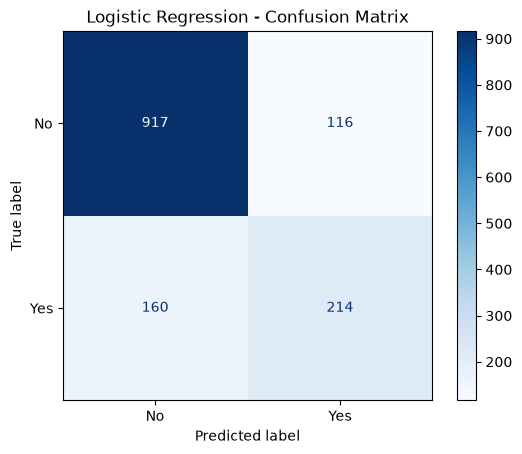

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix display
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

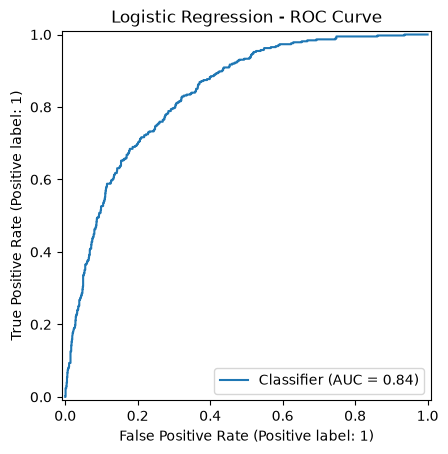

In [16]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test.map({"No": 0, "Yes": 1}),
    y_prob
)

plt.title("Logistic Regression - ROC Curve")
plt.show()

In [17]:
import joblib

joblib.dump(
    logistic_model,
    "../models/logistic_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [18]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.models.train import train_logistic_regression

In [19]:
logistic_model = train_logistic_regression(
    X_train,
    y_train
)

print(logistic_model)

LogisticRegression(max_iter=1000, random_state=42)


In [20]:
from src.models.evaluate import evaluate_model

In [21]:
accuracy, auc = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

Accuracy : 0.8038
ROC-AUC  : 0.8359

Classification Report
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix
[[917 116]
 [160 214]]


In [22]:
from src.models.train import (
    train_logistic_regression,
    train_random_forest
)

In [23]:
from src.models.save_model import save_model

In [24]:
save_model(
    logistic_model,
    "logistic_regression.pkl"
)

Model saved to ..\models\logistic_regression.pkl


In [25]:
random_forest_model = train_random_forest(
    X_train,
    y_train
)

In [26]:
rf_accuracy, rf_auc = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

Accuracy : 0.7910
ROC-AUC  : 0.8302

Classification Report
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1033
         Yes       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix
[[920 113]
 [181 193]]


In [27]:
save_model(
    random_forest_model,
    "random_forest.pkl"
)

Model saved to ..\models\random_forest.pkl


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "ROC-AUC": [
        auc,
        rf_auc
    ]
})

comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.803838,0.835929
1,Random Forest,0.791045,0.830180


In [29]:
from src.models.train import train_xgboost

In [30]:
from src.models.tune import tune_xgboost

In [31]:
best_xgb_model, best_params = tune_xgboost(
    X_train,
    y_train
)

In [32]:
best_params

{'subsample': 0.8,
 'n_estimators': 300,
 'max_depth': 5,
 'learning_rate': 0.01,
 'colsample_bytree': 0.8}

In [33]:
from src.models.evaluate import evaluate_model

In [34]:
best_accuracy, best_auc = evaluate_model(
    best_xgb_model,
    X_test,
    y_test
)

Accuracy : 0.7982
ROC-AUC  : 0.8401

Classification Report
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1033
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407


Confusion Matrix
[[929 104]
 [180 194]]


In [35]:
from src.models.feature_importance import plot_feature_importance

In [37]:
import os

print(os.path.exists("../models/preprocessor.pkl"))

True


In [40]:
import joblib

preprocessor = joblib.load("../models/preprocessor.pkl")

print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [41]:
feature_names = preprocessor.get_feature_names_out()

In [36]:
feature_names = preprocessor.get_feature_names_out()

NameError: name 'preprocessor' is not defined

In [ ]:
import joblib

In [ ]:
preprocessor = joblib.load("../models/preprocessor.pkl")

In [42]:
print(len(feature_names))

45


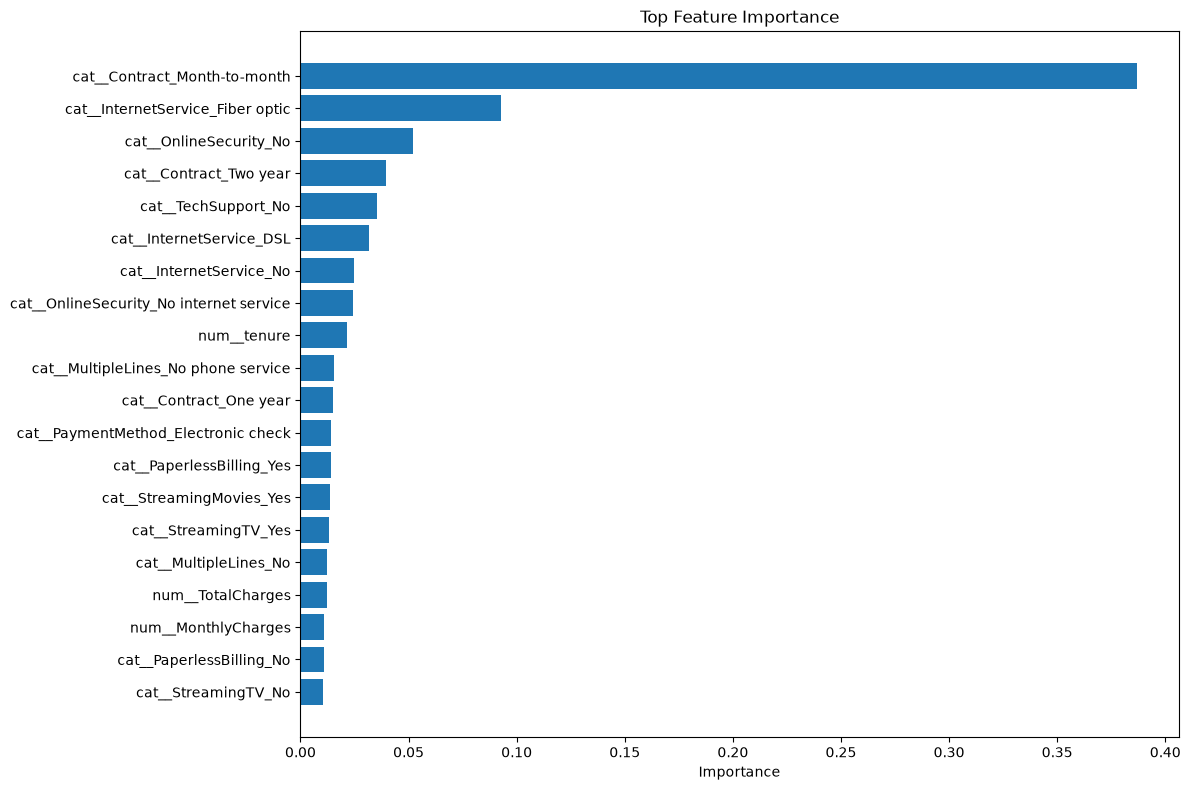

,Feature,Importance
36,cat__Contract_Month-to-month,0.386848
16,cat__InternetService_Fiber optic,0.092704
18,cat__OnlineSecurity_No,0.052084
38,cat__Contract_Two year,0.039713
27,cat__TechSupport_No,0.035227
15,cat__InternetService_DSL,0.031502
17,cat__InternetService_No,0.024624
19,cat__OnlineSecurity_No internet service,0.024436
1,num__tenure,0.021410
13,cat__MultipleLines_No phone service,0.015323


In [43]:
importance = plot_feature_importance(
    best_xgb_model,
    feature_names,
    top_n=20
)

importance.head(20)